In [11]:
########### salary_data #############

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
### Choose the path in your PC where

dataset = pd.read_csv('salary_data.csv')



In [5]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [7]:
print(dataset.head())

   \nYears of Experience  Salary
0                    1.1   39343
1                    1.3   46205
2                    1.5   37731
3                    2.0   43525
4                    2.2   39891


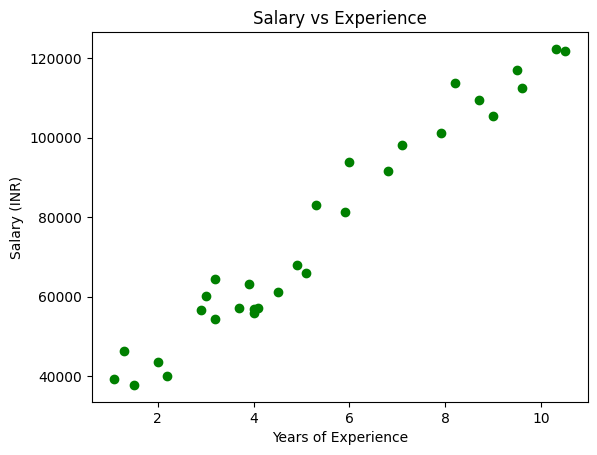

In [8]:
### Lets check if the dataset is linear or not

plt.scatter(X, y, color="green")
plt.title("Salary vs Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (INR)")
plt.show()

In [9]:
###The above graph shows that the dependent and independent variables are linearly dependent.
##So we can apply the simple linear regression on the dataset to find the best relation between these variables.

In [12]:
### Split the dataset into training and testing sets

'''The training set and test set will then be divided into two groups.
We will use 80% observations for the training set and 20%
observations for the test set out of the total 30 observations we have.
So there will be 24 observation in training set and 6 observation in test set.
We divide our dataset into training and test sets so that we can
use one set to train and the other to test our model.'''

'The training set and test set will then be divided into two groups.\nWe will use 80% observations for the training set and 20% \nobservations for the test set out of the total 30 observations we have.\nSo there will be 24 observation in training set and 6 observation in test set.\nWe divide our dataset into training and test sets so that we can\nuse one set to train and the other to test our model.'

In [13]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [14]:
##The next step is fitting our model with the training dataset.
##We will use scikit-learn's LinearRegression class to train a
##simple linear regression model on the training data.
##The code for this is as follows

from sklearn.linear_model import LinearRegression

# Create a linear regression object
regressor= LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [15]:
regressor.coef_   # coefficients
regressor.intercept_   # intercept



np.float64(25499.519363140935)

In [16]:
######## It doesn’t print a statistical model summary (like R², p-values, confidence intervals, etc.).
###### You need to use statsmodels, which is built for statistical analysis.

import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)  # adds the intercept term
model = sm.OLS(y_train, X_train_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     465.5
Date:                Sun, 18 Jan 2026   Prob (F-statistic):           2.72e-16
Time:                        09:51:15   Log-Likelihood:                -242.06
No. Observations:                  24   AIC:                             488.1
Df Residuals:                      22   BIC:                             490.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        2.55e+04   2589.853      9.846      0.0

In [17]:
##Once the model is trained, we can use it to make predictions
##on the test data. The code for this is as follows

y_pred = regressor.predict(X_test)
df = pd.DataFrame({'Actual Values':y_test, 'Predicted Values':y_pred})
print(df)

   Actual Values  Predicted Values
0         101302      99937.018793
1          98273      92399.044167
2          56957      63189.392492
3         116969     115012.968045
4          60150      53766.924210
5          56642      52824.677382


In [18]:
##Here, X_test represents the input feature of the test data and y_pred
##represents the predicted output variable (target variable).

##Similarly, you can test the model with training data.

y_pred = regressor.predict(X_train)
df = pd.DataFrame({'Real Values':y_train, 'Predicted Values':y_pred})
print(df)

    Real Values  Predicted Values
0         83088      75438.601259
1         91738      89572.303683
2         81363      81092.082229
3         39891      46228.949584
4         39343      35864.234474
5         66029      73554.107603
6         63218      62247.145664
7         54445      55651.417866
8         37731      39633.221787
9        113812     102763.759278
10        57189      60362.652008
11       122391     122550.942671
12        61111      67900.626633
13        55794      63189.392492
14        64445      55651.417866
15        46205      37748.728130
16       112635     115955.214873
17        93940      82034.329057
18       121872     124435.436327
19        57081      64131.639320
20       109431     107474.993419
21       105582     110301.733904
22        43525      44344.455928
23        67938      71669.613946


In [20]:
###### Model Evaluation

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# get the predicted values for test dat
y_pred = regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("mse", mse)
rmse = np.sqrt(mse)
print("rsme", rmse)
mae = mean_absolute_error(y_test, y_pred)
print("mae", mae)
r2 = r2_score(y_test, y_pred)
print("r2", r2)

mse 22391819.419990316
rsme 4731.999516059815
mae 4271.293315887506
r2 0.9627560878328097


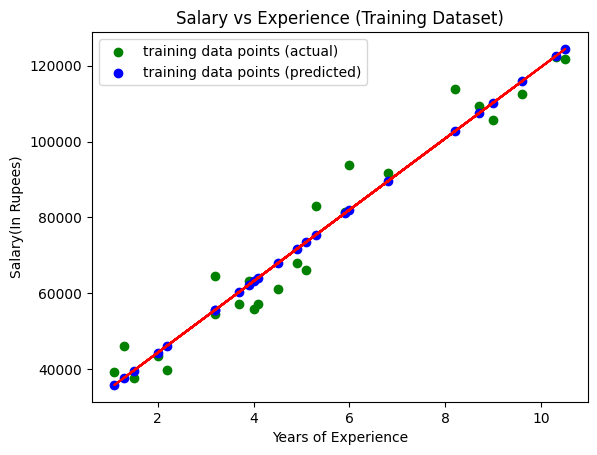

In [21]:
##### Visualize Training Set Results (with Regression Line)

y_pred = regressor.predict(X_train)
plt.scatter(X_train, y_train, color="green", label="training data points (actual)")
plt.scatter(X_train, y_pred, color="blue",label="training data points (predicted)")
plt.plot(X_train, y_pred, color="red")
plt.title("Salary vs Experience (Training Dataset)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary(In Rupees)")
plt.legend()
plt.show()

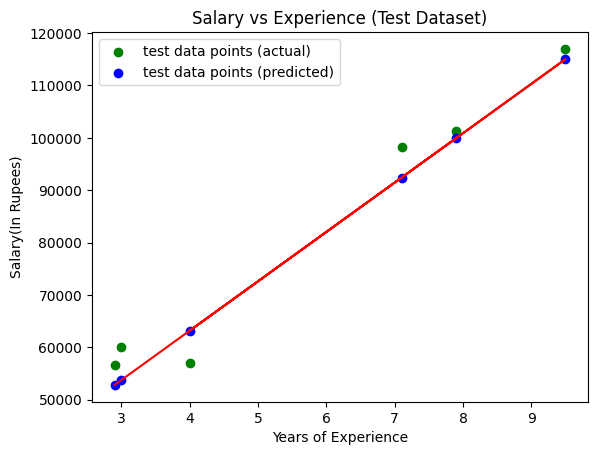

In [22]:
###### Visualize the Test Set Results (with Regression Line)

y_pred = regressor.predict(X_test)
plt.scatter(X_test, y_test, color="green", label="test data points (actual)")
plt.scatter(X_test, y_pred, color="blue",label="test data points (predicted)")
plt.plot(X_test, y_pred, color="red")
plt.title("Salary vs Experience (Test Dataset)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary(In Rupees)")
plt.legend()
plt.show()

In [23]:
import scipy.stats as stats
import matplotlib.pyplot as plt


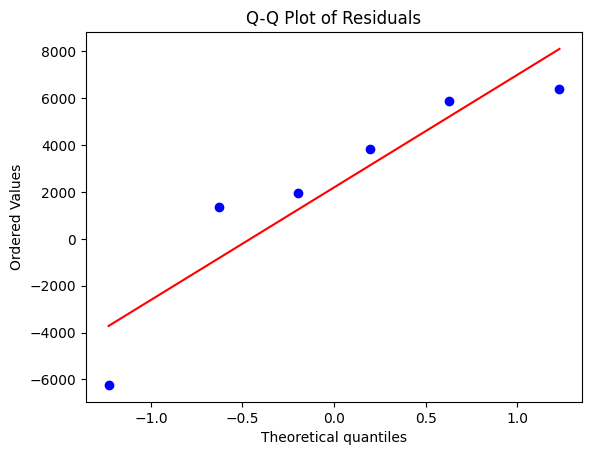

In [25]:
# Calculate residuals
residuals = y_test - y_pred

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [26]:
######### Simulated data to show assumption violation ##############

In [27]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import matplotlib.pyplot as plt

np.random.seed(42)

# 1️⃣ Generate synthetic dataset
n = 200
X = np.random.uniform(0, 10, size=n)
y_true = 1.0 + 2.0 * X + 0.5 * X**2
sigma = 1.0 + 0.6 * X
y = y_true + np.random.randn(n) * sigma

df = pd.DataFrame({"X": X, "y": y, "y_true": y_true, "sigma": sigma})
print(df.head())

          X          y     y_true     sigma
0  3.745401  13.296613  15.504817  3.247241
1  9.507143  66.764266  65.207171  6.704286
2  7.319939  44.010872  42.430635  5.391964
3  5.986585  27.612502  30.892769  4.591951
4  1.560186   8.949812   5.337464  1.936112


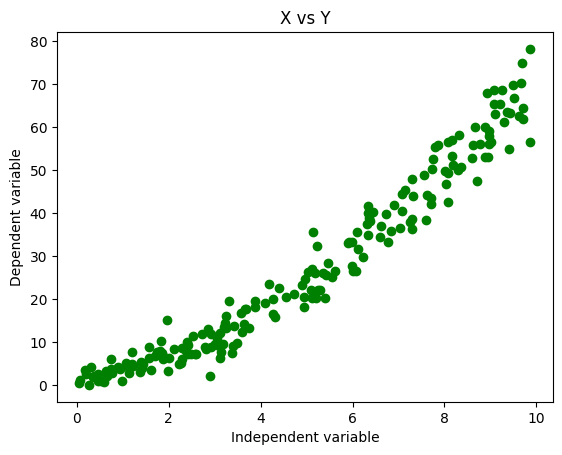

In [28]:
### Lets check if the dataset is linear or not

plt.scatter(X, y, color="green")
plt.title("X vs Y")
plt.xlabel("Independent variable")
plt.ylabel("Dependent variable")
plt.show()

In [29]:
# 2️⃣ Simple Linear Regression (assumption violated)
X_lin = sm.add_constant(X)
ols_lin = sm.OLS(y, X_lin).fit()
y_pred_lin = ols_lin.predict(X_lin)

print("\nLinear model summary:")
print(ols_lin.summary())



Linear model summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     3052.
Date:                Sun, 18 Jan 2026   Prob (F-statistic):          2.88e-122
Time:                        10:02:13   Log-Likelihood:                -615.47
No. Observations:                 200   AIC:                             1235.
Df Residuals:                     198   BIC:                             1242.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.9791      0.

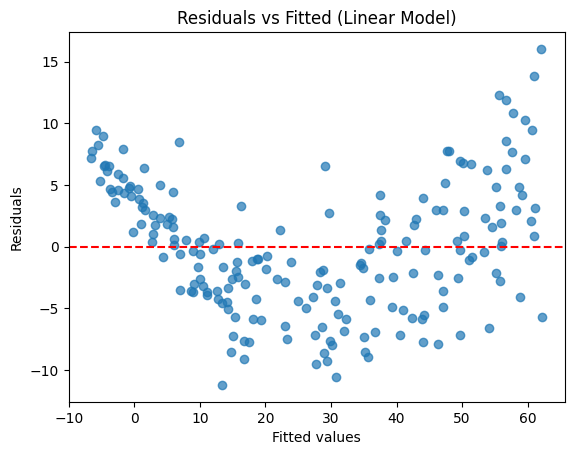

In [30]:
plt.scatter(ols_lin.fittedvalues, ols_lin.resid, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Linear Model)")
plt.show()

In [31]:
# Breusch–Pagan test for heteroscedasticity
bp_test = het_breuschpagan(ols_lin.resid, X_lin)
print("\nBreusch–Pagan test (linear model): p-value =", bp_test[1])




Breusch–Pagan test (linear model): p-value = 0.012409106035352741
